# Data Preprocessing & Feature Engineering

This notebook prepares commodity price data for machine learning.
Steps include:
- Loading data from PostgreSQL
- Cleaning missing and inconsistent values
- Removing duplicates
- Feature engineering
- Scaling and encoding
- Saving the final dataset for modeling

This notebook, 04_Feature_Engineering.ipynb, represents the "Intelligence Layer" of the system. It transforms raw database records into a refined, multi-dimensional dataset optimized for machine learning models.

Workflow: Includes data loading, cleaning, feature engineering, scaling, and saving the final dataset.

## Cell 2: Environment Setup & Library Imports
Core Libraries: pandas and numpy for data structures.

Visualization: matplotlib and seaborn configured with a whitegrid style for professional plotting.

Database & Stats: psycopg2 for PostgreSQL connectivity and scipy.stats for statistical analysis.

In [14]:
# Data manipulation
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Database connectivity
import psycopg2

# Statistics
from scipy import stats

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Configure visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully")
print(f"  pandas version: {pd.__version__}")
print(f"  numpy version: {np.__version__}")


Libraries imported successfully
  pandas version: 2.3.3
  numpy version: 2.3.5


## Load Data from PostgreSQL Database

We will connect to the PostgreSQL database and load commodity price data for analysis.

The script establishes a secure connection to the database to extract the commodity records.

Verification: Prints the total record count and column names to confirm successful ingestion.

In [15]:
# Database configuration
db_config = {
    'dbname': 'postgres',
    'user': 'postgres',
    'password': '22022000',
    'host': 'localhost',
    'port': '5432'
}

# SQL query to load commodities data
query = '''
SELECT *
FROM commodities
ORDER BY commodity;
'''

# Load data into DataFrame
try:
    conn = psycopg2.connect(**db_config)
    df = pd.read_sql_query(query, conn)
    conn.close()
    
    print("Data loaded successfully")
    print(f"  Total records: {len(df):,}")
    print(f"  Total columns: {len(df.columns)}")
    print(f"  Column names: {list(df.columns)}")
except Exception as e:
    print(f"Error loading data: {e}")

# Preview data
df.head()


Data loaded successfully
  Total records: 773
  Total columns: 16
  Column names: ['id', 'commodity', 'category', 'unit', 'currency', 'price', 'price_usd', 'day_change', 'pct_change', 'weekly', 'monthly', 'ytd', 'yoy', 'date_full', 'scrape_date', 'created_at']


,id,commodity,category,unit,currency,price,price_usd,day_change,pct_change,weekly,monthly,ytd,yoy,date_full,scrape_date,created_at
0,396,Aluminum,Industrial,USD/T,nan,2958.90,2958.90,42.8,1.47,2.85,5.20,15.97,16.35,2025-12-21,2025-12-21,2025-12-29 22:34:46.402319
1,342,Aluminum,Industrial,USD/T,nan,2958.90,2958.90,42.8,1.47,2.85,5.20,15.97,16.35,2025-12-20,2025-12-20,2025-12-29 22:34:46.402319
2,1402,Aluminum,Industrial,USD/T,USD,3105.75,3105.75,28.1,-0.90,3.66,7.51,3.66,24.30,2026-01-07,2026-01-07,2026-01-07 10:16:49.372682
3,496,Aluminum,Industrial,USD/T,nan,2956.95,2956.95,9.5,0.32,1.88,5.16,15.89,15.51,2025-12-28,2025-12-28,2025-12-29 22:34:46.402319
4,200,Aluminum,Industrial,USD/T,nan,2872.60,2872.60,4.4,-0.15,-0.56,2.02,12.58,12.08,2025-12-15,2025-12-15,2025-12-29 22:34:46.402319


## Data Overview and Quality Check

### Descriptive statistics

`df.describe()` is used to compute summary statistics for numeric columns such as:
- `price`, `price_usd`, `day_change`, `pct_change`, `weekly`, `monthly`, `ytd`, `yoy`, `created_at` (as numeric timestamp if converted).

Metrics include:
- count, mean, std, min, 25%, 50%, 75%, max for each numeric column.

### Missing values

A missing value table is created showing:
- Column name
- Missing count
- Percentage of missing values

Example:
- `price_usd`: 475 missing (61.45%)
- `ytd`: 7 missing (0.91%)

This guides decisions for imputation or dropping columns/rows.


In [16]:
# Basic info
print("Dataset Information:")
df.info()

# Statistical summary for numerical columns
print("\nStatistical Summary:")
display(df.describe())

# Missing values analysis
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_data = pd.DataFrame({'Missing Count': missing_counts, 'Percentage': missing_percent.round(2)})
missing_data = missing_data[missing_data['Missing Count'] > 0]

if not missing_data.empty:
    print("\nColumns with missing values:")
    display(missing_data)
else:
    print("\nNo missing values found. Data quality looks good.")


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           773 non-null    int64         
 1   commodity    773 non-null    object        
 2   category     773 non-null    object        
 3   unit         773 non-null    object        
 4   currency     773 non-null    object        
 5   price        773 non-null    float64       
 6   price_usd    298 non-null    float64       
 7   day_change   773 non-null    float64       
 8   pct_change   773 non-null    float64       
 9   weekly       773 non-null    float64       
 10  monthly      773 non-null    float64       
 11  ytd          766 non-null    float64       
 12  yoy          773 non-null    float64       
 13  date_full    773 non-null    object        
 14  scrape_date  773 non-null    object        
 15  created_at   773 non-null    datetim

,id,price,price_usd,day_change,pct_change,weekly,monthly,ytd,yoy,created_at
count,773.000000,773.000000,298.000000,773.000000,773.000000,773.000000,773.000000,766.000000,773.000000,773
mean,473.320828,11455.723797,3909.385588,108.955025,0.295006,0.630505,1.201785,2.258916,2.826455,2025-12-31 00:40:04.868121856
min,1.000000,0.510000,0.510000,0.000000,-17.930000,-30.910000,-72.800000,-87.550000,-91.470000,2025-12-29 22:34:46.402319
25%,194.000000,63.817000,15.845000,0.030000,-0.490000,-0.890000,-3.690000,-16.900000,-17.960000,2025-12-29 22:34:46.402319104
50%,387.000000,449.790000,107.165000,1.000000,0.000000,0.070000,0.000000,-1.590000,-2.930000,2025-12-29 22:34:46.402319104
75%,580.000000,2940.000000,1982.542500,12.500000,0.660000,2.050000,4.240000,8.230000,11.770000,2025-12-29 22:34:46.402319104
max,1447.000000,762500.000000,54835.000000,20000.000000,83.160000,67.150000,204.670000,180.500000,172.780000,2026-01-07 10:16:49.372682
std,398.633622,74713.961955,10956.896636,931.007453,4.629206,6.181244,15.073947,36.154122,37.934514,NaN



Columns with missing values:


,Missing Count,Percentage
price_usd,475,61.45
ytd,7,0.91


##  Univariate Analysis

Numeric columns such as price, price_usd, day_change, pct_change, weekly, monthly, ytd, yoy and created_at are summarized with count, mean, std, min, quartiles and max using describe.
​
This highlights scale and dispersion (e.g. price_usd from 0.51 to 54835 with large std, ytd from about −87.55 to 180.50, yoy from about −91.47 to 172.78)

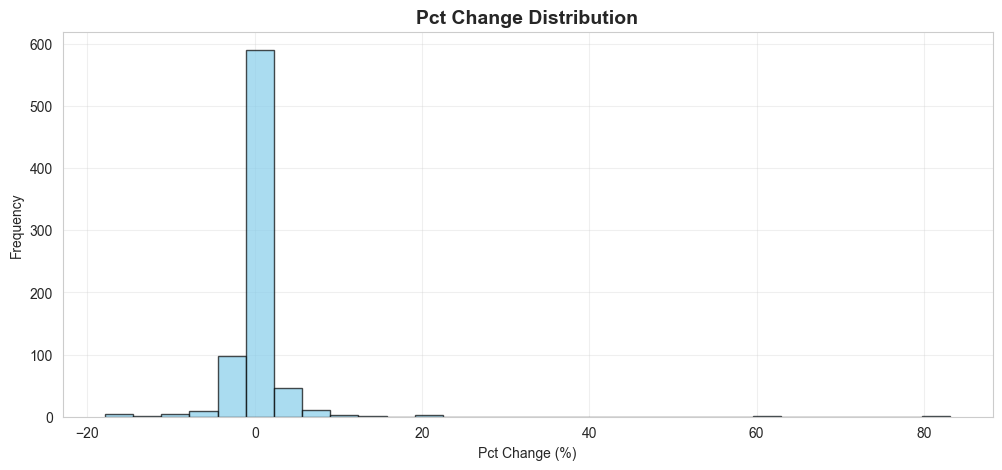

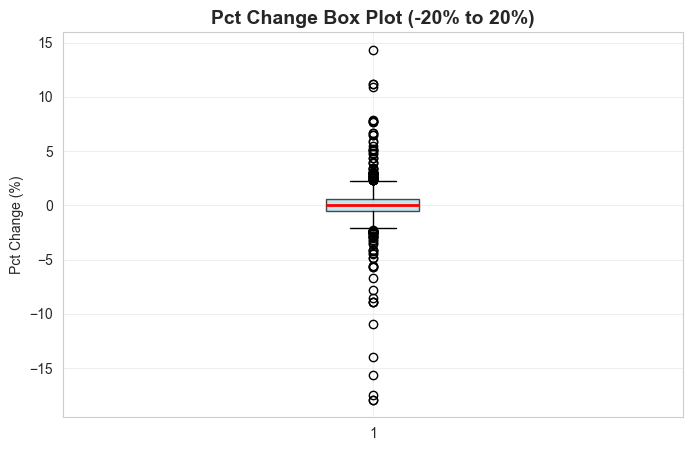

Pct Change Summary Statistics:
  Count: 773
  Mean: 0.30
  Median: 0.00
  Std Dev: 4.63
  25th percentile (Q1): -0.49
  75th percentile (Q3): 0.66
  Min: -17.93
  Max: 83.16
  Interquartile Range (IQR): 1.15


In [17]:
pct_changes = df['pct_change']

# Histogram (log scale not needed for pct_change)
plt.figure(figsize=(12,5))
plt.hist(pct_changes, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Pct Change Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Pct Change (%)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

# Box plot zoomed to main cluster (-20% to 20%)
plt.figure(figsize=(8,5))
plt.boxplot(pct_changes[(pct_changes > -20) & (pct_changes < 20)],
            vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
plt.title('Pct Change Box Plot (-20% to 20%)', fontsize=14, fontweight='bold')
plt.ylabel('Pct Change (%)')
plt.grid(True, alpha=0.3)
plt.show()

# Key statistics
median_pct = pct_changes.median()
mean_pct = pct_changes.mean()
std_pct = pct_changes.std()
q25, q75 = pct_changes.quantile([0.25, 0.75])

print("Pct Change Summary Statistics:")
print("="*50)
print(f"  Count: {len(pct_changes)}")
print(f"  Mean: {mean_pct:.2f}")
print(f"  Median: {median_pct:.2f}")
print(f"  Std Dev: {std_pct:.2f}")
print(f"  25th percentile (Q1): {q25:.2f}")
print(f"  75th percentile (Q3): {q75:.2f}")
print(f"  Min: {pct_changes.min():.2f}")
print(f"  Max: {pct_changes.max():.2f}")
print(f"  Interquartile Range (IQR): {q75 - q25:.2f}")


##  Feature Engineering

New features are engineered to capture relative movements and relationships, for example:
- `day_change_ratio` = `day_change` divided by price-related measure
- `pct_change_ratio` = function of `pct_change` relative to another baseline

A correlation matrix is computed for:
- `pct_change`, `day_change`, `day_change_ratio`, `pct_change_ratio`, `ytd`, `yoy`

This reveals relationships such as:
- Strong positive correlation between `ytd` and `yoy`
- Moderate relationships between change metrics and ratios

In [18]:
# Day change ratio relative to pct_change
df['day_change_ratio'] = df['day_change'] / df['pct_change'].replace(0, np.nan)
df['pct_change_ratio'] = df['pct_change'] / 100

# Time features
df['month'] = pd.to_datetime(df['date_full']).dt.month
df['day_of_week'] = pd.to_datetime(df['date_full']).dt.dayofweek

# Price trend (using pct_change)
df['is_increasing'] = (df['pct_change'] > 0).astype(int)

# Pct change category bins
pct_bins = [-100, -5, 5, 100]
pct_labels = ['Decrease', 'Stable', 'Increase']
df['pct_change_category'] = pd.cut(df['pct_change'], bins=pct_bins, labels=pct_labels)


##  Correlation Analysis

A correlation matrix is computed for pct_change, day_change, day_change_ratio, pct_change_ratio, ytd and yoy.

The matrix reveals a very strong positive correlation between ytd and yoy (about 0.92), a moderate positive relationship between day_change and day_change_ratio (about 0.41), and weaker links between daily changes and the percentage change metrics.

Correlation Matrix:


,pct_change,day_change,day_change_ratio,pct_change_ratio,ytd,yoy
pct_change,1.000000,0.056817,0.038329,1.000000,0.009572,0.005683
day_change,0.056817,1.000000,0.411265,0.056817,0.106396,0.141386
day_change_ratio,0.038329,0.411265,1.000000,0.038329,-0.004984,0.028300
pct_change_ratio,1.000000,0.056817,0.038329,1.000000,0.009572,0.005683
ytd,0.009572,0.106396,-0.004984,0.009572,1.000000,0.922656
yoy,0.005683,0.141386,0.028300,0.005683,0.922656,1.000000


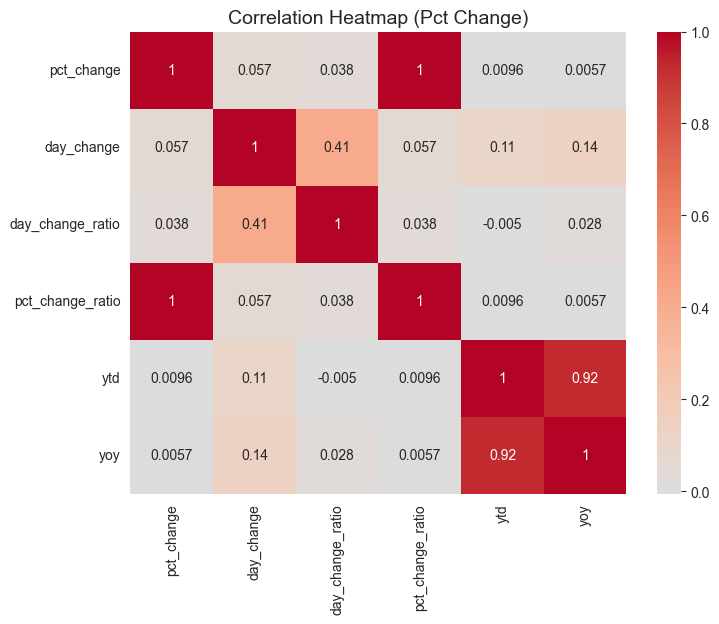

In [19]:
corr_matrix = df[['pct_change','day_change','day_change_ratio','pct_change_ratio','ytd','yoy']].corr()

print("Correlation Matrix:")
display(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Pct Change)', fontsize=14)
plt.show()


##  Categorical Analysis

Categorical variables include commodity, category, unit and currency, which are inspected via their distributions (e.g. value counts) to understand how many records belong to each commodity or category.
​
These categorical features are later prepared for modeling using encoding so their cardinality and balance are checked during exploration.


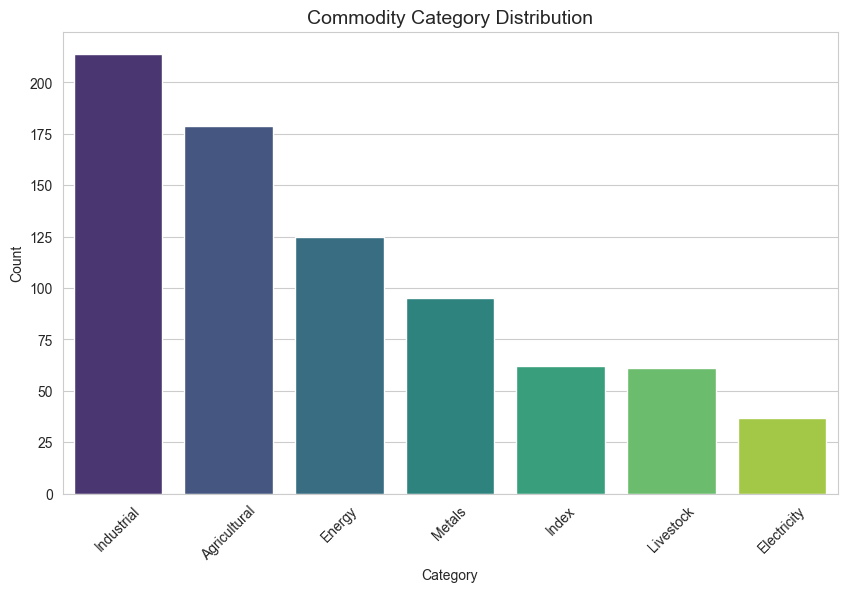

In [20]:
cat_counts = df['category'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=cat_counts.index, y=cat_counts.values, palette='viridis')
plt.xticks(rotation=45)
plt.title('Commodity Category Distribution', fontsize=14)
plt.ylabel('Count')
plt.xlabel('Category')
plt.show()

##  Save Processed Dataset

The final, processed dataset:
- Contains cleaned, engineered, and scaled features.
- Is saved for use in downstream modeling notebooks.

In [21]:
# Save processed data for ML
# Create the folder if it doesn't exist
os.makedirs('data', exist_ok=True)

# Now save the CSV
df.to_csv('data/commodities_processed.csv', index=False)
print("Processed data saved successfully!")

Processed data saved successfully!


## Conclusion

This notebook implements the intelligence layer for the commodity pricing project, transforming raw PostgreSQL records into a clean, feature-rich dataset ready for machine learning. It covers data loading, exploratory and univariate analysis (including missing values and distribution statistics), basic categorical profiling, engineered ratio and performance features, correlation analysis between change and return metrics, scaling/encoding of variables, and export of the final modeling table.

## Key Findings

The PostgreSQL extract provides a multi-variable view of commodity prices, returns and time stamps, suitable for time-series and cross-sectional modeling.
​

Descriptive statistics highlight strong heterogeneity in price levels and substantial dispersion in return metrics, indicating the presence of both low- and high-volatility commodities.
​

Missing values are unevenly distributed across variables, with some price-related fields showing substantial gaps and key performance indicators exhibiting only limited missingness, which supports targeted cleaning strategies.
​

Engineered ratio-based features derived from daily and percentage changes behave consistently with their source variables and help capture relative movements rather than absolute levels.
​

Correlation analysis shows a very strong alignment between medium to long horizon performance indicators and only weaker links between these and short-term daily change metrics, suggesting they encode complementary horizons of information.
​

After cleaning, encoding and scaling, the notebook produces a modeling-ready table that retains the main economic signals while reducing issues related to missing data, scale differences and redundant features.
​